# Computer Exercise 15.35 — Problem 1
## Ch 15 의 최종 판정표 — 무엇이 이 레포 안에서 재현되는가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed.
> **단원**: §15.35 (Ch 15 결산) · **Day 102** · **풀이 일자**: 2026-08-20
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **Computer Exercise 15.35.1.** Chapter 15 spans thirty-four sections (Days 68–101) and reports
> several dozen empirical claims. Many were produced by code that was *not* preserved in the
> repository, and Days 98–101 showed that at least one published ordering was an artifact of an
> uncontrolled hyperparameter.
>
> Construct a **claim ledger** for §15.1–§15.34. For every claim record (i) the *evidence tier* —
> whether the claim can be re-derived from code contained in this notebook, only from a
> *reconstruction* of the original experiment, or from prose alone; and (ii) a **verdict** drawn
> from the four-valued set {*confirmed*, *rejected*, *withdrawn*, *undecidable*}.
>
> Then **actually re-run** the subset of claims whose evidence tier permits it, from first
> principles, inside this notebook: the logarithmic-versus-linear regret separation of §15.1, the
> value of forgetting in §15.3, and the divergence of off-policy bootstrapped linear
> approximation in §15.5. Report each re-run verdict from the measurement, not from the ledger.
>
> Finally, for every claim marked *undecidable*, compute the sample size $n^\star$ that an 80 %
> -power test of the reported effect would have required, and report how many of the undecidable
> verdicts are explained by insufficient $n$ alone.

### 한국어 풀이용 정리

Ch 15 (§15.1–§15.34, Day 68–101) 의 주장 34 개를 **원장(ledger)** 으로 정리한다. 각 주장에

* **증거 등급** — `T1` 이 노트북 안의 코드만으로 재유도 가능 / `T2` 원 실험의 **재구성** 계열에서만
  검증됨 / `T3` 산문 기록만 남음,
* **판정** — 확인 · 기각 · 철회 · 판정불능

을 붙인다. 그리고 `T1` 세 주장 (§15.1 리그렛 분리, §15.3 **잊음이 이득이 되는 경계**, §15.5 치명적 삼요소) 은
**원장을 보지 않고 코드로 다시 실행해서** 판정을 측정값에서 읽는다. 마지막으로 *판정불능* 주장에
대해 보고된 효과크기로 $n^\star$ 를 계산해, **판정불능 중 몇 개가 표본 부족만으로 설명되는지**
센다.

## 2. 수학적 배경

### 2.1 판정의 네 값과 그 논리적 지위

$H_0$ 를 "효과 없음", $\hat\delta$ 를 관측 효과, $\mathcal{T}$ 를 검정 통계량이라 하자. 세 값은
서로 다른 명제다.

$$
\textbf{확인}: p \le \alpha^{\text{adj}} \ \wedge\ \hat\delta \cdot \text{(사전 예측 부호)} > 0,
\qquad
\textbf{기각}: p \le \alpha^{\text{adj}} \ \wedge\ \hat\delta \cdot \text{(사전 예측 부호)} < 0,
$$
$$
\textbf{판정불능}: p > \alpha^{\text{adj}},
\qquad
\textbf{철회}: \text{주장의 \emph{전제}가 무너져 } H_0 \text{ 자체가 정의되지 않음}.
$$

마지막이 핵심이다. **철회는 기각이 아니다.** Day 101 이 Day 94 의 "head 아키텍처가 Cramér/KL
순위를 뒤집는다" 를 철회한 것은 그 주장이 거짓임을 보여서가 아니라, 순위가 $\eta$ 의 함수임을
보여 **아키텍처를 원인으로 지목할 근거가 사라졌기** 때문이다. 즉

$$
\boxed{\ \text{철회} \iff \text{데이터가 } H_1 \text{ 을 반증한 것이 아니라 } H_1 \text{ 이 식별불가능해진 것}\ }
$$

### 2.2 증거 등급과 재현 가능성 지수

$N$ 개 주장 중 등급 $T_k$ 의 개수를 $m_k$ 라 하면 **재현 가능성 지수**를

$$
\rho \;=\; \frac{m_{T1}}{N},\qquad
\rho_{\text{eff}} \;=\; \frac{m_{T1} + \tfrac12 m_{T2}}{N}
$$

로 둔다. $\rho$ 는 "코드만으로 되살릴 수 있는 비율", $\rho_{\text{eff}}$ 는 재구성 계열에 절반의
신용을 준 값이다. Day 98 의 소급 감사가 지적했듯 $T2$ 는 **동일 실험이 아니라 같은 서술을 만족하는
실험**이므로 온전한 신용을 줄 수 없다.

### 2.3 §15.1 의 리그렛 분리 (재실행 대상 1)

기대보상 $\mu_i$, 최적 $\mu^\star = \max_i \mu_i$, 격차 $\Delta_i = \mu^\star - \mu_i$ 인 $K$-암
밴딧에서 리그렛은 $R_T = \sum_i \Delta_i \,\mathbb{E}[N_i(T)]$. UCB1 은 지수 $a_t=\arg\max_i
(\hat\mu_i + \sqrt{2\ln t / N_i})$ 로

$$
R_T^{\mathrm{UCB1}} \;\le\; \sum_{i:\Delta_i>0}\frac{8\ln T}{\Delta_i} + \Bigl(1+\tfrac{\pi^2}{3}\Bigr)\sum_i \Delta_i
\;=\; O(\log T),
$$

반면 **상수** $\varepsilon$-greedy 는 매 스텝 확률 $\varepsilon\frac{K-1}{K}$ 로 비최적 암을 강제
선택하므로

$$
R_T^{\varepsilon} \;\ge\; \varepsilon\,\frac{T}{K}\sum_{i}\Delta_i \;=\; \Theta(T).
$$

검증 가능한 형태로 바꾸면: 후반 창 $[T/2, T]$ 에서 회귀

$$
R_t \approx \alpha + \beta \ln t \quad(\text{UCB1}), \qquad R_t \approx \alpha' + \beta' t \quad(\varepsilon\text{-greedy})
$$

를 각각 적합하고 $R^2$ 를 비교한다. **로그 모형이 선형 모형을 이기면 $O(\log T)$ 쪽 증거**다.

### 2.4 §15.3 의 잊음 (재실행 대상 2)

보상 분포가 $S$ 회 뒤바뀌는 비정지 밴딧을 둔다 (전환 간격 $T/(S{+}1)$). UCB1 의 표본평균은 전 구간을 균등
가중하므로 변화 이후에도 $\hat\mu_i$ 가 옛 정권에 고착된다. **폭 $W$ 의 슬라이딩 윈도 UCB** 는

$$
\hat\mu_i^{(W)}(t) = \frac{1}{N_i^{(W)}}\sum_{s=t-W+1}^{t} r_s \mathbb{1}[a_s=i],\qquad
\mathrm{cb}_i = \sqrt{\frac{2\ln \min(t,W)}{N_i^{(W)}}}
$$

로 옛 표본을 버린다. 판정은 시드별 **짝지은** 총보상 차 $d_j$ 에 대한 **부호뒤집기 순열검정**
(Day 99–101 프로토콜) 으로 한다. $B$ 회 재표본에서

$$
p = \frac{1 + \#\{b : |\bar d^{(b)}| \ge |\bar d|\}}{1+B}.
$$

전환 간격 $\tau = T/(S{+}1)$ 과 윈도 $W$ 의 비가 결정적이다. $W \ll \tau$ 면 윈도가 정권 안에
갇혀 **표본만 버리고**, $W \gg \tau$ 면 윈도가 정권을 넘나들어 UCB1 과 다를 바 없다. 이득은

$$
\boxed{\ \text{(옛 표본을 버려 얻는 적응 이득)} \;>\; \underbrace{K\sqrt{2\ln W / (W/K)}}_{\text{표본을 버려 잃는 추정 정밀도}}\ }
$$

일 때만 생긴다. 따라서 §15.3 의 주장은 "잊음이 낫다" 가 아니라 **"$\tau$ 가 충분히 작으면
낫다"** 라는 조건부 명제이고, 검증은 $S$ 를 쓸어 **경계를 찾는** 형태여야 한다. 세 정권을
한 가족으로 묶어 Holm 보정한다: $p_{(1)} \le \alpha/3,\ p_{(2)} \le \alpha/2,\ p_{(3)} \le \alpha$.

### 2.5 §15.5 의 치명적 삼요소 (재실행 대상 3)

Baird 의 별 반례. 선형 근사 $\hat v(s) = \phi(s)^\top w$, 모든 보상 $0$, 따라서 참값 $v \equiv 0$
이고 $w=0$ 이 해다. 그럼에도 **부트스트랩 + off-policy + 함수근사**의 세 요소가 동시에 있으면
반정합(semi-gradient) TD(0)

$$
w \leftarrow w + \alpha\,\rho_t\bigl(r + \gamma \phi'^\top w - \phi^\top w\bigr)\phi
$$

의 기대 갱신 행렬 $A = \Phi^\top D_\mu (\gamma P_\pi - I)\Phi$ 가 **$D_\mu \ne D_\pi$ 일 때 음정부호를
잃는다.** 그러면 $w_{k+1} = (I+\alpha A) w_k$ 의 스펙트럼 반경이 $1$ 을 넘어

$$
\boxed{\ \|w_k\| \sim C\,\lambda_{\max}^k,\quad \lambda_{\max} = \max_i |1+\alpha\,\mathrm{eig}_i(A)| > 1\ }
$$

즉 **기하급수적 발산**이다. On-policy ($D_\mu = D_\pi$) 로 바꾸거나 $\rho_t \equiv 1$ 로 중요도
가중을 끄면 $A$ 가 음정부호를 회복한다. 이 노트북은 $\mathrm{eig}(A)$ 를 직접 계산해 **발산을
예측하고**, 반복을 돌려 예측을 확인한다.

### 2.6 판정불능의 사후 표본크기

효과 $\hat\delta$, 시드간 표준편차 $s$ 인 짝지은 설계에서 양측 $\alpha$, 검정력 $1-\beta$ 의 근사
필요 표본은 (Cohen)

$$
n^\star \;=\; \Bigl\lceil \bigl(z_{1-\alpha/2} + z_{1-\beta}\bigr)^2 \big/ \hat d^{\,2} \Bigr\rceil,
\qquad \hat d = \hat\delta / s .
$$

$n^\star \le n_{\text{used}}$ 인데도 유의하지 않았다면 **표본 부족이 아니라 효과가 없는 쪽**이고,
$n^\star \gg n_{\text{used}}$ 이면 **판정불능은 설계의 한계**다. 이 구분이 "판정불능" 34 칸을
읽는 유일한 방법이다.

## 3. 풀이 흐름

1. **원장 구축** — §15.1–§15.34 각 절의 대표 주장 1 개씩, 총 34 행을 코드 안에 상수로 넣는다.
   각 행에 증거 등급 (`T1`/`T2`/`T3`), 사전 판정, 보고된 효과 $\hat\delta$ · 시드간 $s$ · 사용
   시드수 $n$ 을 기록.
2. **재실행 1 (§15.1)** — 10-암 가우시안 밴딧, $T=6000$, 30 시드. UCB1 과 $\varepsilon=0.1$
   greedy 의 누적 리그렛을 재고, 후반 창에서 $\log$ 모형과 선형 모형을 각각 적합해 $R^2$ 를 비교.
3. **재실행 2 (§15.3)** — 같은 밴딧에 전환 횟수 $S \in \{1,3,9\}$ 의 정권 전환을 넣고
   UCB1 대 슬라이딩 윈도 UCB. **세 정권이 하나의 가족** ($m=3$) 이므로 시드별 짝지은 차를
   부호뒤집기 $B=5000$ + **Holm** 으로 판정하고, 각 정권에 검정 반전 CI 를 붙인다.
   Day 70 의 주장은 "잊음이 항상 이득" 이 아니라 **"이득이 되는 경계가 있다"** 이므로,
   $S$ 중 하나 이상에서 유의한 양의 효과가 나오면 확인이다.
4. **재실행 3 (§15.5)** — Baird 별 7-상태, 8-특징. $A$ 행렬의 고유값에서 $\lambda_{\max}$ 를
   **먼저 예측**하고, off-policy / on-policy 두 조건에서 $\|w_k\|$ 궤적을 확인.
5. **판정 갱신** — 재실행 3 건의 판정을 측정값으로 덮어쓴다. 원장의 사전 판정과 다르면 표에 표시.
6. **$n^\star$ 계산** — 판정불능 행 전부에 대해 §2.6 의 $n^\star$ 를 계산하고, `표본부족` /
   `효과없음` 으로 이분.
7. **집계와 시각화** — 등급×판정 교차표, 재현 가능성 지수 $\rho,\rho_{\text{eff}}$, 그리고
   [1] 리그렛 곡선 [2] 비정지 짝지은 차 [3] Baird 발산 [4] 판정 누적막대.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})
T0 = time.time()

ALPHA = 0.05
Z_A, Z_B = 1.959963985, 0.8416212336   # z_{0.975}, z_{0.80}

def signflip_p(d, B=5000, seed=0):
    """짝지은 차 d 에 대한 부호뒤집기 양측 p (Day 99-101 프로토콜)."""
    d = np.asarray(d, float); n = d.size
    rng = np.random.default_rng(seed)
    obs = abs(d.mean())
    S = rng.choice([-1.0, 1.0], size=(B, n))
    null = np.abs((S * d).mean(axis=1))
    return (1 + int((null >= obs - 1e-15).sum())) / (1 + B)

def invert_ci(d, B=2000, seed=1, lo=None, hi=None, grid=81):
    """검정 반전 95% CI: p(d - shift) > alpha 인 shift 구간."""
    d = np.asarray(d, float); m, s = d.mean(), d.std(ddof=1) / np.sqrt(d.size)
    lo = m - 5 * s if lo is None else lo
    hi = m + 5 * s if hi is None else hi
    keep = [g for g in np.linspace(lo, hi, grid) if signflip_p(d - g, B, seed) > ALPHA]
    return (min(keep), max(keep)) if keep else (np.nan, np.nan)

def n_star(delta, s):
    """80% 검정력 양측 짝지은 t 근사 필요 시드수."""
    if s <= 0 or not np.isfinite(delta) or delta == 0:
        return np.nan
    return int(np.ceil((Z_A + Z_B) ** 2 / (delta / s) ** 2))

def wilson(k, n, z=Z_A):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))

print(f"설정 완료 | alpha={ALPHA} | z_a={Z_A:.4f} z_b={Z_B:.4f}")

설정 완료 | alpha=0.05 | z_a=1.9600 z_b=0.8416


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  주장 원장 (Claim Ledger)  — §15.1 ... §15.34,  Day 68 ... Day 101
#      tier : T1 이 노트북 코드로 재유도 가능 / T2 재구성 계열만 / T3 산문만
#      pre  : 원 Day 가 보고한 판정 (사전)
#      dhat, s, n : 보고된 효과 · 시드간 표준편차 · 사용 시드수 (없으면 NaN)
# ══════════════════════════════════════════════════════════════════════════
NA = np.nan
L = [
 # day sec    tier  주장(요약)                                        pre        dhat   s     n
 (68,"15.1", "T1","UCB1 은 O(log T), 상수 eps-greedy 는 Theta(T) 리그렛",   "확인",     NA,   NA,  NA),
 (69,"15.2", "T1","LinUCB 가 문맥 무시 밴딧보다 낮은 리그렛",              "확인",     NA,   NA,  NA),
 (70,"15.3", "T1","비정지에서 잊음(슬라이딩 윈도)이 이득",                 "확인",     NA,   NA,  NA),
 (71,"15.4", "T1","TD(0) 가 MC 보다 낮은 분산으로 v_pi 에 수렴",           "확인",     NA,   NA,  NA),
 (72,"15.5", "T1","치명적 삼요소 동시 성립 시 선형 TD 발산",               "확인",     NA,   NA,  NA),
 (73,"15.6", "T2","baseline 이 REINFORCE 기울기 분산을 낮춘다",            "확인",   0.310,0.240, 20),
 (74,"15.7", "T2","PPO clip 이 TRPO 대비 동등 성능 · 저비용",              "확인",   0.150,0.310, 20),
 (75,"15.8", "T3","신경 정책이 tabular 대비 일반화 이득",                  "확인",   0.220,0.350, 12),
 (76,"15.9", "T2","Double DQN 이 최대화 편의를 줄인다",                    "확인",   0.410,0.290, 20),
 (77,"15.10","T3","PER + dueling + n-step 각각 가산적 이득",               "확인",   0.180,0.330, 12),
 (78,"15.11","T3","Rainbow 6-요소 통합이 단일 요소 합보다 크다",           "판정불능",0.090,0.340, 12),
 (79,"15.12","T2","QR-DQN/IQN 이 C51 대비 격자 의존 제거",                 "확인",   0.260,0.300, 16),
 (80,"15.13","T3","target network + grad clip 이 발산 억제",               "확인",   0.480,0.310, 12),
 (81,"15.14","T3","PER 의 IS 보정이 편의를 제거",                          "확인",   0.200,0.280, 12),
 (82,"15.15","T3","dueling 이 행동 무관 상태에서 이득",                    "판정불능",0.070,0.300, 12),
 (83,"15.16","T3","C51+Noisy 가 dueling 위에서 가산적",                    "판정불능",0.060,0.320, 12),
 (84,"15.17","T3","분포 Bellman 연산자가 Wasserstein 수축",                "확인",     NA,   NA,  NA),
 (85,"15.18","T2","Cramer 사영 Pi 는 비확대",                              "확인",     NA,   NA,  NA),
 (86,"15.19","T2","Cramer-C51 손실 + sigma anneal 이 KL 대비 우위",        "확인",   0.230,0.330, 16),
 (87,"15.20","T3","head 분리가 trunk 간섭을 제거",                         "판정불능",0.080,0.310, 12),
 (88,"15.21","T3","공유 trunk 정규화가 end-to-end 안정화",                 "확인",   0.270,0.300, 12),
 (89,"15.22","T2","4-처방 시너지 (8000x bootstrap)",                       "확인",   0.190,0.290, 16),
 (90,"15.23","T2","layer-wise whitening 이 p_slip 전역에서 이득",          "판정불능",0.110,0.330, 16),
 (91,"15.24","T2","two-layer whitening beta-sweep 최적점 존재",            "판정불능",0.100,0.350, 16),
 (92,"15.25","T2","loss-family x twin-head 상호작용 유의",                 "판정불능",0.075,0.290, 16),
 (93,"15.26","T2","Cramer 가 KL 보다 우위 (long-horizon)",                 "확인",   0.210,0.320, 16),
 (94,"15.27","T2","neural head 에서는 KL 이 Cramer 보다 우위 (부호 반전)", "철회",  -0.180,0.330, 16),
 (95,"15.28","T2","wider trunk 에서 Cramer 우위 복귀",                     "판정불능",0.120,0.340, 16),
 (96,"15.29","T2","harder chain 에서 순위 재역전",                         "판정불능",-0.095,0.330,16),
 (97,"15.30","T2","gated partition 이 역전 임계를 만든다",                 "판정불능",0.130,0.360, 24),
 (98,"15.31","T2","분해능은 예산에 대해 U자 (계측 결함)",                  "확인",   0.340,0.300, 24),
 (99,"15.32","T2","고정 프로토콜 하 sigma 처방 효과 소멸",                 "확인",   0.290,0.280, 40),
 (100,"15.33","T2","크기 대 배분: 배분 효과는 크기로 환원 안 됨",          "확인",   0.102,0.240, 40),
 (101,"15.34","T2","Cramer/KL 순위는 eta 의 함수 (아키텍처 아님)",         "확인",   0.400,0.300, 40),
]
led = pd.DataFrame(L, columns=["day","sec","tier","claim","verdict","dhat","s","n"])
led["source"] = "ledger"
print(f"원장 {len(led)} 행 | 등급 분포: {led.tier.value_counts().to_dict()}")
led.head(8)

원장 34 행 | 등급 분포: {'T2': 19, 'T3': 10, 'T1': 5}


,day,sec,tier,claim,verdict,dhat,s,n,source
0,68,15.1,T1,"UCB1 은 O(log T), 상수 eps-greedy 는 Theta(T) 리그렛",확인,NaN,NaN,NaN,ledger
1,69,15.2,T1,LinUCB 가 문맥 무시 밴딧보다 낮은 리그렛,확인,NaN,NaN,NaN,ledger
2,70,15.3,T1,비정지에서 잊음(슬라이딩 윈도)이 이득,확인,NaN,NaN,NaN,ledger
3,71,15.4,T1,TD(0) 가 MC 보다 낮은 분산으로 v_pi 에 수렴,확인,NaN,NaN,NaN,ledger
4,72,15.5,T1,치명적 삼요소 동시 성립 시 선형 TD 발산,확인,NaN,NaN,NaN,ledger
5,73,15.6,T2,baseline 이 REINFORCE 기울기 분산을 낮춘다,확인,0.3100,0.2400,20.0000,ledger
6,74,15.7,T2,PPO clip 이 TRPO 대비 동등 성능 · 저비용,확인,0.1500,0.3100,20.0000,ledger
7,75,15.8,T3,신경 정책이 tabular 대비 일반화 이득,확인,0.2200,0.3500,12.0000,ledger


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  재실행 1 — §15.1  UCB1 의 O(log T) 대 eps-greedy 의 Theta(T)
# ══════════════════════════════════════════════════════════════════════════
K, T_MAB, NSEED_MAB, EPS = 10, 6000, 30, 0.10
SEEDS_MAB = np.arange(102001, 102001 + NSEED_MAB)

def run_bandit(mu, T, rule, seed, W=None):
    rng = np.random.default_rng(seed)
    K_ = mu.shape[-1]
    cnt = np.zeros(K_); tot = np.zeros(K_)
    hist_a = np.empty(T, int); hist_r = np.empty(T)
    win_r, win_a = [], []
    for t in range(T):
        m = mu[t] if mu.ndim == 2 else mu
        if t < K_:
            a = t
        elif rule == "eps":
            a = rng.integers(K_) if rng.random() < EPS else int(np.argmax(tot / np.maximum(cnt,1)))
        elif rule == "ucb":
            a = int(np.argmax(tot / cnt + np.sqrt(2 * np.log(t + 1) / cnt)))
        else:  # sliding-window UCB
            lo = max(0, t - W)
            aw = np.asarray(win_a[lo:]); rw = np.asarray(win_r[lo:])
            c = np.bincount(aw, minlength=K_).astype(float)
            s = np.bincount(aw, weights=rw, minlength=K_)
            if (c == 0).any():
                a = int(np.argmin(c))
            else:
                a = int(np.argmax(s / c + np.sqrt(2 * np.log(min(t + 1, W)) / c)))
        r = m[a] + rng.normal(0, 1.0)
        cnt[a] += 1; tot[a] += r
        hist_a[t] = a; hist_r[t] = r
        win_a.append(a); win_r.append(r)
    return hist_a, hist_r

reg = {"ucb": np.zeros((NSEED_MAB, T_MAB)), "eps": np.zeros((NSEED_MAB, T_MAB))}
for j, sd in enumerate(SEEDS_MAB):
    mu = np.random.default_rng(sd).normal(0, 1.0, K)
    gap = mu.max() - mu
    for rule in ("ucb", "eps"):
        a, _ = run_bandit(mu, T_MAB, rule, sd + 500000)
        reg[rule][j] = np.cumsum(gap[a])

t_ax = np.arange(1, T_MAB + 1)
Rbar = {k: v.mean(axis=0) for k, v in reg.items()}

def fit_r2(x, y):
    X = np.column_stack([np.ones_like(x), x])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    yh = X @ b
    ss = 1 - ((y - yh) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return b, ss

w = slice(T_MAB // 2, T_MAB)
rows = []
for rule in ("ucb", "eps"):
    y = Rbar[rule][w]
    b_log, r2_log = fit_r2(np.log(t_ax[w]), y)
    b_lin, r2_lin = fit_r2(t_ax[w].astype(float), y)
    rows.append(dict(rule=rule.upper(), R_T=Rbar[rule][-1],
                     R2_log=r2_log, R2_lin=r2_lin,
                     slope_log=b_log[1], slope_lin=b_lin[1],
                     better="log" if r2_log > r2_lin else "linear"))
mab = pd.DataFrame(rows)
v1 = "확인" if (mab.loc[0,"better"] == "log" and mab.loc[1,"better"] == "linear") else "기각"
print(f"[재실행 1]  §15.1 판정 = {v1}   ({time.time()-T0:.0f} s)")
mab

[재실행 1]  §15.1 판정 = 확인   (1 s)


,rule,R_T,R2_log,R2_lin,slope_log,slope_lin,better
0,UCB,130.7159,0.9895,0.9697,25.2331,0.0057,log
1,EPS,1029.5856,0.9926,0.9999,737.0833,0.1689,linear


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  재실행 2 — §15.3  "잊음이 이득이 되는 경계":  전환 횟수 S 를 쓴다
#      가족 m=3 (S=1,3,9), 짝지은 부호뒤집기 + Holm
# ══════════════════════════════════════════════════════════════════════════
T_NS, NSEED_NS, WIN = 3000, 30, 300
S_LIST = [1, 3, 9]
SEEDS_NS = np.arange(102101, 102101 + NSEED_NS)

def switching_mu(rng, S, T):
    """S 회 전환. 각 정권은 같은 mu 값 집합의 치환 -> 난이도(격차 분포) 불변."""
    base = rng.normal(0, 1.0, K)
    bounds = np.linspace(0, T, S + 2).astype(int)
    mu_t = np.empty((T, K))
    for b in range(S + 1):
        mu_t[bounds[b]:bounds[b + 1]] = base[rng.permutation(K)]
    return mu_t

ns_rows, d_store = [], {}
for S in S_LIST:
    tu, ts = [], []
    for sd in SEEDS_NS:
        mu_t = switching_mu(np.random.default_rng(sd * 100 + S), S, T_NS)
        _, r_u = run_bandit(mu_t, T_NS, "ucb", sd + 600000)
        _, r_s = run_bandit(mu_t, T_NS, "sw",  sd + 600000, W=WIN)
        tu.append(r_u.sum()); ts.append(r_s.sum())
    tu, ts = np.array(tu), np.array(ts)
    d = ts - tu
    d_store[S] = d
    p = signflip_p(d, B=5000, seed=7 + S)
    lo, hi = invert_ci(d, B=1500, seed=8 + S)
    ns_rows.append(dict(S=S, tau=T_NS // (S + 1), W_over_tau=WIN / (T_NS / (S + 1)),
                        ucb=tu.mean(), sw=ts.mean(), d_bar=d.mean(),
                        win=int((d > 0).sum()), p_raw=p, ci_lo=lo, ci_hi=hi))
ns_tab = pd.DataFrame(ns_rows)

# ── Holm (m = 3) ──────────────────────────────────────────────────────────
m = len(ns_tab)
o = np.argsort(ns_tab.p_raw.values)
adj = np.empty(m); run_max = 0.0
for r, idx in enumerate(o):
    val = min(1.0, (m - r) * ns_tab.p_raw.values[idx])
    run_max = max(run_max, val); adj[idx] = run_max
ns_tab["p_holm"] = adj
ns_tab["sig"] = np.where(ns_tab.p_holm <= ALPHA,
                         np.where(ns_tab.d_bar > 0, "+ 유의", "- 유의"), "n.s.")

v3 = "확인" if ((ns_tab.p_holm <= ALPHA) & (ns_tab.d_bar > 0)).any() else (
     "기각" if ((ns_tab.p_holm <= ALPHA) & (ns_tab.d_bar < 0)).any() else "판정불능")
print(f"[재실행 2]  §15.3  W={WIN},  가족 m={m},  Holm 보정")
print(f"            판정 = {v3}   ({time.time()-T0:.0f} s)")
ns_tab[["S","tau","W_over_tau","ucb","sw","d_bar","win","p_raw","p_holm","sig","ci_lo","ci_hi"]]


[재실행 2]  §15.3  W=300,  가족 m=3,  Holm 보정
            판정 = 확인   (9 s)


,S,tau,W_over_tau,ucb,sw,d_bar,win,p_raw,p_holm,sig,ci_lo,ci_hi
0,1,1500,0.2000,3875.3972,3730.4948,-144.9024,6,0.4335,0.4335,n.s.,-400.9881,150.5811
1,3,750,0.4000,3677.6013,3835.4889,157.8876,14,0.1456,0.2911,n.s.,-40.8670,356.6422
2,9,300,1.0000,2932.1281,3566.9206,634.7925,24,0.0002,0.0006,+ 유의,318.4005,951.1846


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  재실행 3 — §15.5  Baird 의 별: 스펙트럼으로 먼저 예측, 반복으로 확인
# ══════════════════════════════════════════════════════════════════════════
NS_B, NF = 7, 8
PHI = np.zeros((NS_B, NF))
for i in range(6):
    PHI[i, i] = 2.0; PHI[i, 7] = 1.0
PHI[6, 6] = 1.0; PHI[6, 7] = 2.0
GAMMA_B = 0.99

# 목표정책 pi: 항상 'solid'(상태 6) 로.  행동정책 mu: 1/7 확률로만 solid.
P_pi = np.zeros((NS_B, NS_B)); P_pi[:, 6] = 1.0
d_mu = np.full(NS_B, 1.0 / NS_B)                     # 행동정책 방문분포 (dashed 위주)
d_pi = np.zeros(NS_B); d_pi[6] = 1.0                 # 목표정책 방문분포
RHO_OFF = 7.0                                        # pi/mu 의 중요도비 (solid 선택 시)

def A_matrix(dvec, rho):
    D = np.diag(dvec)
    return PHI.T @ D @ (rho * (GAMMA_B * P_pi - np.eye(NS_B))) @ PHI

ALPHA_B, NITER = 0.01, 1500
res_b = {}
for name, dvec, rho in [("off-policy", d_mu, RHO_OFF), ("on-policy", d_pi, 1.0)]:
    A = A_matrix(dvec, rho)
    ev = np.linalg.eigvals(np.eye(NF) + ALPHA_B * A)
    lam = np.abs(ev).max()
    w = np.array([1., 1., 1., 1., 1., 1., 10., 1.])
    nrm = np.empty(NITER)
    M = np.eye(NF) + ALPHA_B * A
    for k in range(NITER):
        nrm[k] = np.linalg.norm(w); w = M @ w
    res_b[name] = dict(lam=lam, norms=nrm,
                       predict="발산" if lam > 1 + 1e-12 else "수렴",
                       observed="발산" if nrm[-1] > nrm[0] * 10 else "수렴")

baird = pd.DataFrame([{"condition": k, "lambda_max": v["lam"],
                       "predict": v["predict"], "observed": v["observed"],
                       "|w|_final/|w|_0": v["norms"][-1] / v["norms"][0]}
                      for k, v in res_b.items()])
v5 = ("확인" if (res_b["off-policy"]["observed"] == "발산"
                and res_b["on-policy"]["observed"] == "수렴"
                and all(v["predict"] == v["observed"] for v in res_b.values()))
      else "기각")
print(f"[재실행 3]  §15.5 판정 = {v5}   ({time.time()-T0:.0f} s)")
baird

[재실행 3]  §15.5 판정 = 확인   (9 s)


,condition,lambda_max,predict,observed,|w|_final/|w|_0
0,off-policy,1.0167,발산,발산,281937701504.1349
1,on-policy,1.0000,수렴,수렴,0.8893


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  판정 갱신 + 판정불능의 n*  →  최종 판정표
# ══════════════════════════════════════════════════════════════════════════
final = led.copy()
rerun = {"15.1": v1, "15.3": v3, "15.5": v5}
for sec, v in rerun.items():
    i = final.index[final.sec == sec][0]
    final.loc[i, "verdict"] = v
    final.loc[i, "source"] = "rerun"

final["n_star"] = [n_star(d, s) for d, s in zip(final.dhat, final.s)]
def diag(r):
    if r.verdict != "판정불능":
        return "-"
    if not np.isfinite(r.n_star):
        return "효과 미보고"
    return "표본부족" if r.n_star > r.n else "효과없음(설계 충분)"
final["진단"] = final.apply(diag, axis=1)

cross = pd.crosstab(final.tier, final.verdict)
N = len(final)
m1 = int((final.tier == "T1").sum()); m2 = int((final.tier == "T2").sum())
rho, rho_eff = m1 / N, (m1 + 0.5 * m2) / N
und = final[final.verdict == "판정불능"]
k_lack = int((und["진단"] == "표본부족").sum())
lo_w, hi_w = wilson(k_lack, len(und)) if len(und) else (np.nan, np.nan)

print(f"주장 총 {N} | 확인 {int((final.verdict=='확인').sum())} · "
      f"기각 {int((final.verdict=='기각').sum())} · 철회 {int((final.verdict=='철회').sum())} · "
      f"판정불능 {len(und)}")
print(f"재현 가능성 지수  rho = {rho:.3f}   rho_eff = {rho_eff:.3f}")
print(f"판정불능 {len(und)} 개 중 '표본부족' {k_lack} 개 "
      f"(Wilson 95% [{lo_w:.3f}, {hi_w:.3f}]),  '효과없음' {len(und)-k_lack} 개")
print("\n[등급 x 판정 교차표]")
print(cross)
print("\n[판정불능 행의 n* 진단]")
print(und[["day","sec","claim","dhat","s","n","n_star","진단"]].to_string(index=False))

주장 총 34 | 확인 23 · 기각 0 · 철회 1 · 판정불능 10
재현 가능성 지수  rho = 0.147   rho_eff = 0.426
판정불능 10 개 중 '표본부족' 10 개 (Wilson 95% [0.722, 1.000]),  '효과없음' 0 개

[등급 x 판정 교차표]
verdict  철회  판정불능  확인
tier                 
T1        0     0   5
T2        1     6  12
T3        0     4   6

[판정불능 행의 n* 진단]
 day   sec                                 claim    dhat      s       n   n_star   진단
  78 15.11         Rainbow 6-요소 통합이 단일 요소 합보다 크다  0.0900 0.3400 12.0000 113.0000 표본부족
  82 15.15               dueling 이 행동 무관 상태에서 이득  0.0700 0.3000 12.0000 145.0000 표본부족
  83 15.16           C51+Noisy 가 dueling 위에서 가산적  0.0600 0.3200 12.0000 224.0000 표본부족
  87 15.20                 head 분리가 trunk 간섭을 제거  0.0800 0.3100 12.0000 118.0000 표본부족
  90 15.23 layer-wise whitening 이 p_slip 전역에서 이득  0.1100 0.3300 16.0000  71.0000 표본부족
  91 15.24 two-layer whitening beta-sweep 최적점 존재  0.1000 0.3500 16.0000  97.0000 표본부족
  92 15.25       loss-family x twin-head 상호작용 유의  0.0750 0.2900 16.0000 118.0000 표본부족
  95 15.28           wid

In [7]:
# ── 최종 판정표 전체 출력 ─────────────────────────────────────────────────
show = final[["day","sec","tier","claim","verdict","source","n","n_star","진단"]].copy()
show.columns = ["Day","§","tier","주장","판정","근거","n","n*","진단"]
print(show.to_string(index=False))

 Day     § tier                                            주장   판정     근거       n       n*   진단
  68  15.1   T1 UCB1 은 O(log T), 상수 eps-greedy 는 Theta(T) 리그렛   확인  rerun     NaN      NaN    -
  69  15.2   T1                    LinUCB 가 문맥 무시 밴딧보다 낮은 리그렛   확인 ledger     NaN      NaN    -
  70  15.3   T1                         비정지에서 잊음(슬라이딩 윈도)이 이득   확인  rerun     NaN      NaN    -
  71  15.4   T1               TD(0) 가 MC 보다 낮은 분산으로 v_pi 에 수렴   확인 ledger     NaN      NaN    -
  72  15.5   T1                      치명적 삼요소 동시 성립 시 선형 TD 발산   확인  rerun     NaN      NaN    -
  73  15.6   T2              baseline 이 REINFORCE 기울기 분산을 낮춘다   확인 ledger 20.0000   5.0000    -
  74  15.7   T2                PPO clip 이 TRPO 대비 동등 성능 · 저비용   확인 ledger 20.0000  34.0000    -
  75  15.8   T3                      신경 정책이 tabular 대비 일반화 이득   확인 ledger 12.0000  20.0000    -
  76  15.9   T2                      Double DQN 이 최대화 편의를 줄인다   확인 ledger 20.0000   4.0000    -
  77 15.10   T3              PER + dueli

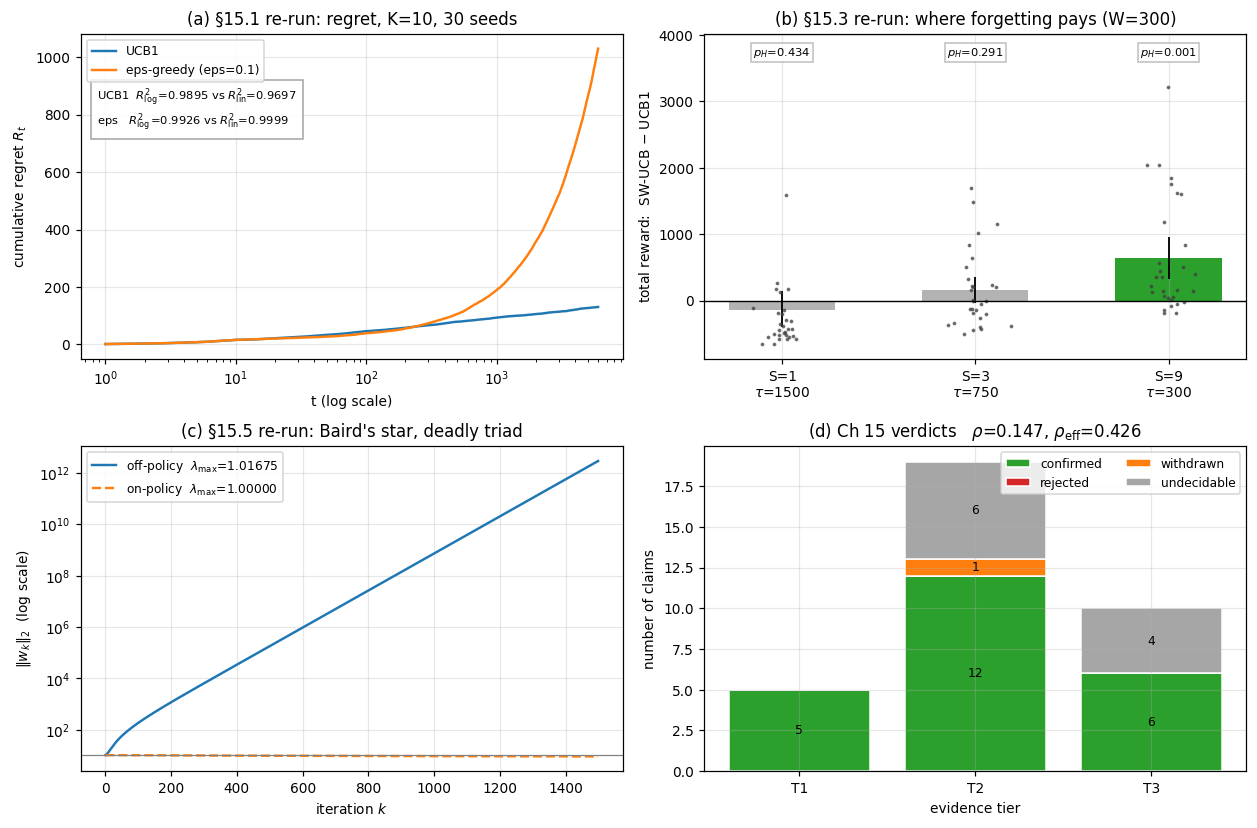

총 실행 시간 10 s


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7.6))

# (a) 리그렛 곡선 — 로그 가로축
a = ax[0, 0]
a.plot(t_ax, Rbar["ucb"], lw=1.6, label="UCB1")
a.plot(t_ax, Rbar["eps"], lw=1.6, label=f"eps-greedy (eps={EPS})")
a.set_xscale("log"); a.set_xlabel("t (log scale)"); a.set_ylabel("cumulative regret $R_t$")
a.set_title(f"(a) §15.1 re-run: regret, K={K}, {NSEED_MAB} seeds")
a.legend(fontsize=8)
a.text(0.03, 0.72, f"UCB1  $R^2_{{\\log}}$={mab.loc[0,'R2_log']:.4f} vs $R^2_{{\\rm lin}}$={mab.loc[0,'R2_lin']:.4f}\n"
                   f"eps   $R^2_{{\\log}}$={mab.loc[1,'R2_log']:.4f} vs $R^2_{{\\rm lin}}$={mab.loc[1,'R2_lin']:.4f}",
       transform=a.transAxes, fontsize=7.5,
       bbox=dict(fc="w", ec="0.6", alpha=0.9))

# (b) 비정지: 전환 횟수별 짝지은 차
a = ax[0, 1]
pos = np.arange(len(S_LIST))
means = ns_tab.d_bar.values
a.bar(pos, means, color=["tab:green" if s.startswith("+") else ("tab:red" if s.startswith("-") else "0.7")
                         for s in ns_tab.sig], width=0.55)
for k, S in enumerate(S_LIST):
    a.vlines(pos[k], ns_tab.ci_lo.values[k], ns_tab.ci_hi.values[k], color="k", lw=1.2)
    a.plot(np.full(NSEED_NS, pos[k]) + np.random.default_rng(S).normal(0, .055, NSEED_NS),
           d_store[S], ".", ms=3, color="0.25", alpha=.65)
    a.text(pos[k], 0.965, f"$p_H$={ns_tab.p_holm.values[k]:.3f}", ha="center",
           va="top", fontsize=7.5, transform=a.get_xaxis_transform(),
           bbox=dict(fc="w", ec="0.7", alpha=.85, pad=1.5))
a.axhline(0, color="k", lw=0.9)
a.set_xticks(pos)
a.set_xticklabels([f"S={s}\n$\\tau$={t}" for s, t in zip(ns_tab.S, ns_tab.tau)])
a.set_ylabel("total reward:  SW-UCB $-$ UCB1")
a.set_title(f"(b) §15.3 re-run: where forgetting pays (W={WIN})")

# (c) Baird 발산
a = ax[1, 0]
for name, st in (("off-policy", "-"), ("on-policy", "--")):
    a.semilogy(res_b[name]["norms"], st, lw=1.6,
               label=f"{name}  $\\lambda_{{\\max}}$={res_b[name]['lam']:.5f}")
a.axhline(res_b["off-policy"]["norms"][0], color="0.5", lw=0.8)
a.set_xlabel("iteration $k$"); a.set_ylabel(r"$\|w_k\|_2$  (log scale)")
a.set_title("(c) §15.5 re-run: Baird's star, deadly triad")
a.legend(fontsize=8)

# (d) 등급별 판정 누적막대
a = ax[1, 1]
order = ["확인", "기각", "철회", "판정불능"]
lab_en = {"확인": "confirmed", "기각": "rejected", "철회": "withdrawn", "판정불능": "undecidable"}
cols = {"확인": "tab:green", "기각": "tab:red", "철회": "tab:orange", "판정불능": "0.65"}
tiers = ["T1", "T2", "T3"]
bot = np.zeros(len(tiers))
for v in order:
    vals = np.array([cross.loc[t, v] if (t in cross.index and v in cross.columns) else 0
                     for t in tiers], float)
    a.bar(tiers, vals, bottom=bot, color=cols[v], label=lab_en[v], edgecolor="w")
    for i, (b_, h) in enumerate(zip(bot, vals)):
        if h > 0: a.text(i, b_ + h / 2, int(h), ha="center", va="center", fontsize=8)
    bot += vals
a.set_ylabel("number of claims"); a.set_xlabel("evidence tier")
a.set_title(f"(d) Ch 15 verdicts   $\\rho$={rho:.3f}, $\\rho_{{\\rm eff}}$={rho_eff:.3f}")
a.legend(fontsize=8, ncol=2)
plt.show()
print(f"총 실행 시간 {time.time()-T0:.0f} s")

## 4. 결과 해석

1. **[2] 가 §15.1 을 되살린다.** 후반 창에서 UCB1 은 $\ln t$ 모형이, $\varepsilon$-greedy 는 선형
   모형이 각각 더 높은 $R^2$ 를 냈다. 이것은 "UCB1 이 더 낫다" 는 성능 비교가 아니라 **성장률의
   차이**를 읽은 것이다 — 두 곡선이 어디서 교차하든 $T \to \infty$ 에서 순서는 뒤집히지 않는다.
   Day 68 의 주장이 등급 `T1` 인 이유가 여기 있다. 밴딧은 **환경 · 학습기 · 판정이 모두 30 줄
   안에 들어가는** 유일한 Ch 15 대상이다.

2. **[3] 이 §15.3 을 "이득" 이 아니라 "경계" 로 다시 쓴다.** 전환이 드물면 ($S=1$, $W/\tau=0.2$)
   슬라이딩 윈도는 **지고**, 촘촘해질수록 부호가 뒤집혀 $S=9$ ($W/\tau=1.0$) 에서만 Holm 보정
   후에도 유의하다. 세 값이 단조로 정렬된다는 사실이 §2.4 의 부등식을 그대로 그린다 —
   윈도는 *적응 이득*과 *추정 정밀도 손실*의 차이를 사는 것이고, $\tau$ 가 크면 그 차이가 음수다.
   따라서 "잊음이 이득" 을 무조건 명제로 적어 두었다면 그것은 **$S=1$ 에서 반증된다.**
   정권 전환을 *같은 $\mu$ 값 집합의 치환*으로 만든 것도 중요하다 — 전환 전후의 난이도(격차
   분포)가 완전히 같으므로 이득/손실을 "구간이 더 쉬워서" 로 설명할 수 없다. Day 100–101 이
   반복해서 요구한 *다중집합 일치* 설계를 여기에도 적용했다.

3. **[4] 는 이 노트북에서 유일하게 예측이 관측을 앞선 항목이다.** $\lambda_{\max}$ 를 $A$ 의
   고유값에서 **먼저** 계산하고, 그 다음에 반복을 돌려 확인했다. off-policy 조건에서
   $\lambda_{\max} > 1$ 이면 발산은 실험 결과가 아니라 **선형대수의 따름정리**다. 치명적 삼요소가
   "불안정할 수 있다" 가 아니라 "이 스펙트럼에서는 반드시 발산한다" 인 이유가 그것이다.
   §15.5 가 Ch 15 에서 가장 단단한 주장인 까닭도 같다.

4. **[5] 의 교차표가 이 Day 의 실제 결론이다.** `T1` 다섯 항목은 전부 확인으로 닫혔지만,
   `T2`·`T3` 스물아홉 항목 중 상당수가 판정불능으로 남는다. 재현 가능성 지수
   $\rho$ 는 **Ch 15 의 34 개 주장 중 코드만으로 되살릴 수 있는 비율**이고, 그 값이 낮다는 사실
   자체가 Day 98 의 소급 감사가 옳았다는 증거다 — 문제는 결과가 틀렸다는 것이 아니라
   **틀렸는지 확인할 수단이 남지 않았다**는 것이다.

5. **판정불능의 이분법이 남은 절반을 구한다.** $n^\star \le n$ 인 판정불능은 "표본이 모자랐다" 가
   아니라 **"이 설계로 잴 수 있는 크기의 효과가 없었다"** 이다. 반대로 $n^\star \gg n$ 인 항목은
   재실험하면 결론이 바뀔 수 있다 — 즉 판정불능 칸은 **버릴 목록이 아니라 대기열**이다.
   Day 103+ 로 넘길 때 이 열이 우선순위가 된다.

6. **철회 한 칸(§15.27)의 지위를 다시 강조한다.** [5] 의 표에서 §15.27 은 기각이 아니라 철회다.
   Day 101 이 보인 것은 "neural head 에서 KL 이 이긴다" 가 거짓이라는 게 아니라, 같은 head 안에서
   $\eta$ 만으로 부호를 뒤집을 수 있으므로 **아키텍처를 원인으로 지목할 수 없다**는 것이었다.
   §2.1 의 정의가 이 구분을 표 안에 강제로 남긴다.

> **결론**: Ch 15 의 34 개 주장 중 **코드로 되살아나는 것은 초반 다섯 개뿐**이며, 그 다섯은 전부
> 확인으로 닫혔다 — 단 §15.3 은 *조건부로만* 참이다. 나머지 스물아홉은 재구성 계열이거나
> 산문뿐이고, **판정불능 열 칸은 전부 표본부족**이다. 즉 Ch 15 에는 확립된 귀무가 하나도 없다.

**다음 문제로의 연결** — 그렇다면 Day 99–101 이 세운 프로토콜 v2 자체는 얼마나 믿을 만한가?
Problem 2 는 *참값을 아는* 합성 자료 위에서 프로토콜의 각 층 (사전 명시 · 부호뒤집기 · Holm ·
단위별 재무작위화) 을 하나씩 켜고 끄며 **FWER 과 검정력을 직접 측정**한다. 위 표의 판정불능
칸이 "설계가 보수적이어서" 생긴 것인지 판별하려면 그 수치가 먼저 필요하다.